In [3]:
# Importa as bibliotecas necessárias para o pré-processamento
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

# Carrega o DataFrame limpo salvo na etapa anterior
df = pd.read_csv('/home/jander/churn_telco/data/processed/telco_churn_limpo.csv')

# Confirma que carregou corretamente
print(f"Shape: {df.shape}")
print(df[['contract', 'tenure', 'onlinesecurity', 'techsupport', 'internetservice', 'churn']].head())

Shape: (7043, 22)
         contract  tenure onlinesecurity techsupport internetservice churn
0  Month-to-month       1             No          No             DSL    No
1        One year      34            Yes          No             DSL    No
2  Month-to-month       2            Yes          No             DSL   Yes
3        One year      45            Yes         Yes             DSL    No
4  Month-to-month       2             No          No     Fiber optic   Yes


In [4]:
# Seleciona apenas as 5 variáveis com maior IV e a variável alvo
# descartamos totalcharges por data leakage
colunas_selecionadas = ['contract', 'tenure', 'onlinesecurity', 
                        'techsupport', 'internetservice', 'churn_bin']

# Cria um novo DataFrame apenas com as colunas selecionadas
df_model = df[colunas_selecionadas].copy()  # .copy() evita warnings de alteração

# Confirma o resultado
print(f"Shape: {df_model.shape}")
print(df_model.head())

Shape: (7043, 6)
         contract  tenure onlinesecurity techsupport internetservice  \
0  Month-to-month       1             No          No             DSL   
1        One year      34            Yes          No             DSL   
2  Month-to-month       2            Yes          No             DSL   
3        One year      45            Yes         Yes             DSL   
4  Month-to-month       2             No          No     Fiber optic   

   churn_bin  
0          0  
1          0  
2          1  
3          0  
4          1  


In [5]:
# Aplica Label Encoding em contract — há ordem natural de comprometimento
# Month-to-month=0 (menos comprometido), One year=1, Two year=2 (mais comprometido)
contrato_ordem = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df_model['contract'] = df_model['contract'].map(contrato_ordem)

# Aplica One Hot Encoding nas demais categóricas
# drop_first=True evita a dummy trap removendo uma categoria redundante
df_model = pd.get_dummies(df_model, 
                          columns=['internetservice', 'onlinesecurity', 'techsupport'],
                          drop_first=True)

# Confirma o resultado — mostra as novas colunas criadas
print(f"Shape: {df_model.shape}")
print(df_model.columns.tolist())
print(df_model.head())

Shape: (7043, 9)
['contract', 'tenure', 'churn_bin', 'internetservice_Fiber optic', 'internetservice_No', 'onlinesecurity_No internet service', 'onlinesecurity_Yes', 'techsupport_No internet service', 'techsupport_Yes']
   contract  tenure  churn_bin  internetservice_Fiber optic  \
0         0       1          0                        False   
1         1      34          0                        False   
2         0       2          1                        False   
3         1      45          0                        False   
4         0       2          1                         True   

   internetservice_No  onlinesecurity_No internet service  onlinesecurity_Yes  \
0               False                               False               False   
1               False                               False                True   
2               False                               False                True   
3               False                               False                True

In [6]:
# Move churn_bin para a última coluna
colunas = [c for c in df_model.columns if c != 'churn_bin'] + ['churn_bin']
df_model = df_model[colunas]

# Confirma resultado final
print(f"Shape: {df_model.shape}")
print(df_model.head())

Shape: (7043, 9)
   contract  tenure  internetservice_Fiber optic  internetservice_No  \
0         0       1                        False               False   
1         1      34                        False               False   
2         0       2                        False               False   
3         1      45                        False               False   
4         0       2                         True               False   

   onlinesecurity_No internet service  onlinesecurity_Yes  \
0                               False               False   
1                               False                True   
2                               False                True   
3                               False                True   
4                               False               False   

   techsupport_No internet service  techsupport_Yes  churn_bin  
0                            False            False          0  
1                            False            False  

In [7]:
# Converte colunas booleanas True/False para inteiro 1/0
df_model = df_model.astype(
    {col: int for col in df_model.select_dtypes(include='bool').columns}
)

# Confirma que não há mais booleanos
print(df_model.dtypes)
print(df_model.head())

contract                              int64
tenure                                int64
internetservice_Fiber optic           int64
internetservice_No                    int64
onlinesecurity_No internet service    int64
onlinesecurity_Yes                    int64
techsupport_No internet service       int64
techsupport_Yes                       int64
churn_bin                             int64
dtype: object
   contract  tenure  internetservice_Fiber optic  internetservice_No  \
0         0       1                            0                   0   
1         1      34                            0                   0   
2         0       2                            0                   0   
3         1      45                            0                   0   
4         0       2                            1                   0   

   onlinesecurity_No internet service  onlinesecurity_Yes  \
0                                   0                   0   
1                                  

In [8]:
from sklearn.preprocessing import MinMaxScaler  # importa o normalizador

# Cria o scaler — vai transformar os valores para a escala 0 a 1
scaler = MinMaxScaler()

# Aplica a normalização apenas em tenure
# tenure vai de 0 a 72 — precisamos colocar na mesma escala das outras variáveis
df_model['tenure'] = scaler.fit_transform(df_model[['tenure']])

# Confirma o resultado — min deve ser 0.0 e max deve ser 1.0
print(f"tenure min: {df_model['tenure'].min()}")
print(f"tenure max: {df_model['tenure'].max()}")
print(df_model.head())

tenure min: 0.0
tenure max: 1.0
   contract    tenure  internetservice_Fiber optic  internetservice_No  \
0         0  0.013889                            0                   0   
1         1  0.472222                            0                   0   
2         0  0.027778                            0                   0   
3         1  0.625000                            0                   0   
4         0  0.027778                            1                   0   

   onlinesecurity_No internet service  onlinesecurity_Yes  \
0                                   0                   0   
1                                   0                   1   
2                                   0                   1   
3                                   0                   1   
4                                   0                   0   

   techsupport_No internet service  techsupport_Yes  churn_bin  
0                                0                0          0  
1                         

In [9]:
# Separa as features (X) do alvo (y)
X = df_model.drop(columns=['churn_bin'])  # tudo menos o alvo
y = df_model['churn_bin']                 # só o alvo

# Divide em 80% treino e 20% teste
# random_state=42 garante reprodutibilidade — sempre o mesmo split
# stratify=y garante que a proporção de churn seja igual em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape}")
print(f"Teste:  {X_test.shape}")
print(f"\nProporção de churn no treino: {y_train.mean().round(2)}")
print(f"Proporção de churn no teste:  {y_test.mean().round(2)}")

Treino: (5634, 8)
Teste:  (1409, 8)

Proporção de churn no treino: 0.27
Proporção de churn no teste:  0.27


In [10]:
from imblearn.over_sampling import SMOTE  # importa o SMOTE

# Cria o SMOTE com random_state para reprodutibilidade
smote = SMOTE(random_state=42)

# Aplica SMOTE apenas no treino — NUNCA no teste!
# o teste deve refletir a realidade, não dados sintéticos
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Confirma o balanceamento
print(f"Treino antes do SMOTE: {y_train.value_counts().to_dict()}")
print(f"Treino depois do SMOTE: {y_train_bal.value_counts().to_dict()}")
print(f"\nShape treino balanceado: {X_train_bal.shape}")

Treino antes do SMOTE: {0: 4139, 1: 1495}
Treino depois do SMOTE: {0: 4139, 1: 4139}

Shape treino balanceado: (8278, 8)


In [11]:
from sklearn.linear_model import LogisticRegression  # importa o modelo
from sklearn.metrics import classification_report, confusion_matrix  # métricas

# Cria o modelo de regressão logística
# max_iter=1000 garante que o modelo tenha iterações suficientes para convergir
modelo_lr = LogisticRegression(random_state=42, max_iter=1000)

# Treina o modelo com os dados balanceados pelo SMOTE
modelo_lr.fit(X_train_bal, y_train_bal)

# Faz previsões no conjunto de teste (dados reais, sem SMOTE)
y_pred = modelo_lr.predict(X_test)

# Exibe o relatório de classificação
print(classification_report(y_test, y_pred, target_names=['Não Cancelou', 'Cancelou']))

              precision    recall  f1-score   support

Não Cancelou       0.90      0.73      0.80      1035
    Cancelou       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [12]:
from sklearn.ensemble import RandomForestClassifier  # importa Random Forest
from xgboost import XGBClassifier                    # importa XGBoost
from sklearn.metrics import classification_report    # métricas de avaliação

# Dicionário com os três modelos para testar
modelos = {
    'Regressão Logística': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest':       RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost':             XGBClassifier(random_state=42, eval_metric='logloss')
}

# Treina e avalia cada modelo
for nome, modelo in modelos.items():
    # Treina com dados balanceados pelo SMOTE
    modelo.fit(X_train_bal, y_train_bal)
    
    # Faz previsões no conjunto de teste real
    y_pred = modelo.predict(X_test)
    
    print(f"\n{'='*50}")
    print(f"MODELO: {nome}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, 
                                target_names=['Não Cancelou', 'Cancelou']))


MODELO: Regressão Logística
              precision    recall  f1-score   support

Não Cancelou       0.90      0.73      0.80      1035
    Cancelou       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


MODELO: Random Forest
              precision    recall  f1-score   support

Não Cancelou       0.87      0.76      0.81      1035
    Cancelou       0.51      0.68      0.58       374

    accuracy                           0.74      1409
   macro avg       0.69      0.72      0.70      1409
weighted avg       0.77      0.74      0.75      1409


MODELO: XGBoost
              precision    recall  f1-score   support

Não Cancelou       0.88      0.75      0.81      1035
    Cancelou       0.51      0.72      0.60       374

    accuracy                           0.74      1409
   macro avg       0.70      0.74      0.71      1409
weigh

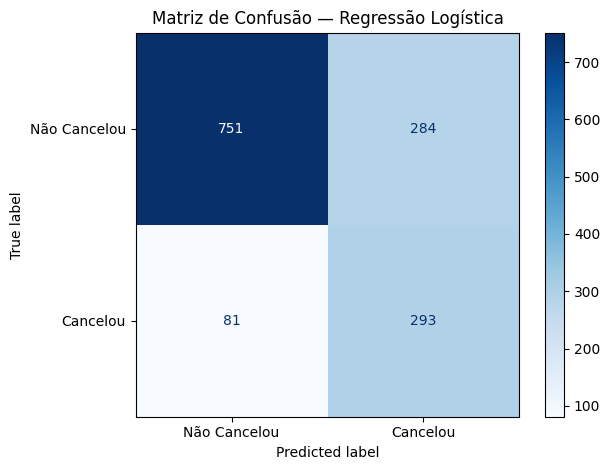


Verdadeiro Negativo  (acertou Não Cancelou): 751
Falso Positivo       (disse Cancelou, era Não): 284
Falso Negativo       (disse Não Cancelou, era Cancelou): 81
Verdadeiro Positivo  (acertou Cancelou): 293


In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Gera as previsões do modelo de regressão logística
y_pred_lr = modelo_lr.predict(X_test)

# Calcula a matriz de confusão
cm = confusion_matrix(y_test, y_pred_lr)

# Exibe a matriz de confusão de forma visual
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Não Cancelou', 'Cancelou'])
disp.plot(cmap='Blues')  # esquema de cores azul

plt.title('Matriz de Confusão — Regressão Logística')
plt.tight_layout()
plt.show()

# Exibe também os números para facilitar a leitura
print(f"\nVerdadeiro Negativo  (acertou Não Cancelou): {cm[0][0]}")
print(f"Falso Positivo       (disse Cancelou, era Não): {cm[0][1]}")
print(f"Falso Negativo       (disse Não Cancelou, era Cancelou): {cm[1][0]}")
print(f"Verdadeiro Positivo  (acertou Cancelou): {cm[1][1]}")

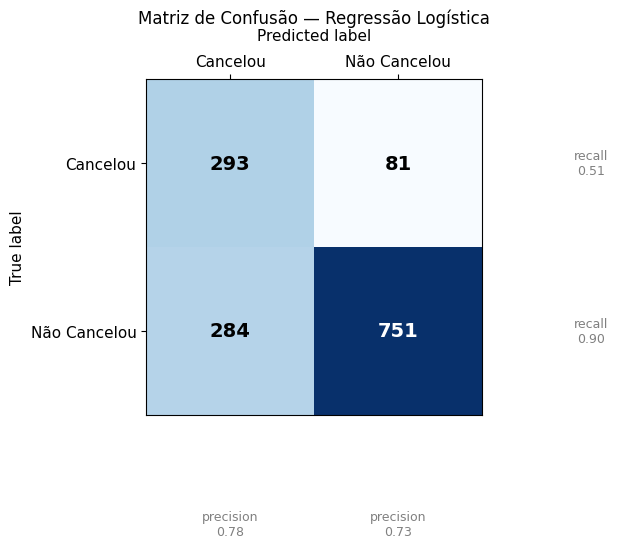

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Calcula a matriz de confusão
cm = confusion_matrix(y_test, y_pred_lr)

# Reorganiza para [[Cancelou/Cancelou, Cancelou/NãoCancelou],
#                  [NãoCancelou/Cancelou, NãoCancelou/NãoCancelou]]
cm_reorg = cm[::-1, ::-1]  # inverte linhas e colunas

# Calcula precision e recall para cada classe
tp_c  = cm_reorg[0, 0]  # verdadeiro positivo cancelou
fp_c  = cm_reorg[0, 1]  # falso positivo cancelou
fn_c  = cm_reorg[1, 0]  # falso negativo cancelou
tp_nc = cm_reorg[1, 1]  # verdadeiro positivo não cancelou
fp_nc = cm_reorg[1, 0]  # falso positivo não cancelou
fn_nc = cm_reorg[0, 1]  # falso negativo não cancelou

precision_c  = tp_c  / (tp_c  + fp_c)   # precision de cancelou
precision_nc = tp_nc / (tp_nc + fp_nc)  # precision de não cancelou
recall_c     = tp_c  / (tp_c  + fn_c)   # recall de cancelou
recall_nc    = tp_nc / (tp_nc + fn_nc)  # recall de não cancelou

# Cria figura com espaço extra para labels
fig, ax = plt.subplots(figsize=(8, 6))

# Plota a matriz de confusão
im = ax.imshow(cm_reorg, cmap='Blues')

# Labels das classes
classes = ['Cancelou', 'Não Cancelou']

# Coloca os nomes das colunas em cima
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(classes, fontsize=11)
ax.set_yticklabels(classes, fontsize=11)
ax.set_xlabel('Predicted label', fontsize=11, labelpad=10)
ax.set_ylabel('True label', fontsize=11)

# Adiciona os valores dentro das células
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_reorg[i, j]),
                ha='center', va='center',
                fontsize=14, fontweight='bold',
                color='white' if cm_reorg[i, j] > cm_reorg.max()/2 else 'black')

# Adiciona precision ao fim de cada linha (lado direito)
ax.text(2.15, 0, f'recall\n{recall_c:.2f}',
        ha='center', va='center', fontsize=9, color='gray')
ax.text(2.15, 1, f'recall\n{recall_nc:.2f}',
        ha='center', va='center', fontsize=9, color='gray')

# Adiciona recall ao fim de cada coluna (parte inferior)
ax.text(0, 2.15, f'precision\n{precision_c:.2f}',
        ha='center', va='center', fontsize=9, color='gray')
ax.text(1, 2.15, f'precision\n{precision_nc:.2f}',
        ha='center', va='center', fontsize=9, color='gray')

plt.title('Matriz de Confusão — Regressão Logística', pad=40)
plt.tight_layout()
plt.show()

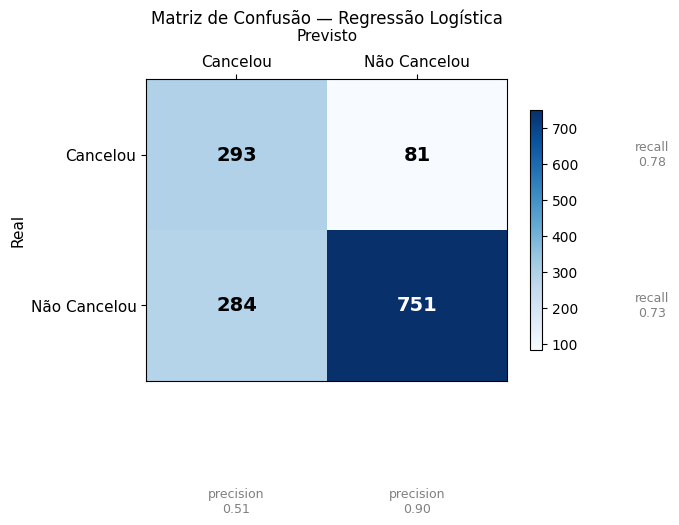

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import confusion_matrix

# Calcula a matriz de confusão
cm = confusion_matrix(y_test, y_pred_lr)
cm_reorg = cm[::-1, ::-1]  # inverte para Cancelou ficar primeiro

# Calcula precision e recall
precision_c  = cm_reorg[0,0] / (cm_reorg[0,0] + cm_reorg[1,0])
precision_nc = cm_reorg[1,1] / (cm_reorg[1,1] + cm_reorg[0,1])
recall_c     = cm_reorg[0,0] / (cm_reorg[0,0] + cm_reorg[0,1])
recall_nc    = cm_reorg[1,1] / (cm_reorg[1,1] + cm_reorg[1,0])

fig, ax = plt.subplots(figsize=(7, 6))

# Plota com gradiente de cor correto baseado nos valores
im = ax.imshow(cm_reorg, cmap='Blues', aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)  # barra de gradiente lateral

classes = ['Cancelou', 'Não Cancelou']

# Nomes das colunas em cima
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(classes, fontsize=11)
ax.set_yticklabels(classes, fontsize=11)
ax.set_xlabel('Previsto', fontsize=11, labelpad=10)
ax.set_ylabel('Real', fontsize=11)

# Valores dentro das células com cor adaptativa
thresh = cm_reorg.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_reorg[i, j]),
                ha='center', va='center', fontsize=14, fontweight='bold',
                color='white' if cm_reorg[i, j] > thresh else 'black')

# Precision e recall discretos nas bordas
for i, recall in enumerate([recall_c, recall_nc]):
    ax.text(2.3, i, f'recall\n{recall:.2f}',
            ha='center', va='center', fontsize=9, color='gray')

for j, precision in enumerate([precision_c, precision_nc]):
    ax.text(j, 2.3, f'precision\n{precision:.2f}',
            ha='center', va='center', fontsize=9, color='gray')

plt.title('Matriz de Confusão — Regressão Logística', pad=40, fontsize=12)
plt.tight_layout()
plt.show()

In [16]:
# Seleciona todas as variáveis com IV > 0.1 mais o alvo
colunas_v2 = ['contract', 'tenure', 'onlinesecurity', 'techsupport',
              'internetservice', 'onlinebackup', 'deviceprotection',
              'monthlycharges', 'paymentmethod', 'streamingmovies',
              'streamingtv', 'paperlessbilling', 'dependents',
              'partner', 'seniorcitizen', 'churn_bin']

# Cria novo DataFrame com todas as variáveis selecionadas
df_v2 = df[colunas_v2].copy()

# Confirma shape e primeiras linhas
print(f"Shape: {df_v2.shape}")
print(df_v2.head())

Shape: (7043, 16)
         contract  tenure onlinesecurity techsupport internetservice  \
0  Month-to-month       1             No          No             DSL   
1        One year      34            Yes          No             DSL   
2  Month-to-month       2            Yes          No             DSL   
3        One year      45            Yes         Yes             DSL   
4  Month-to-month       2             No          No     Fiber optic   

  onlinebackup deviceprotection  monthlycharges              paymentmethod  \
0          Yes               No           29.85           Electronic check   
1           No              Yes           56.95               Mailed check   
2          Yes               No           53.85               Mailed check   
3           No              Yes           42.30  Bank transfer (automatic)   
4           No               No           70.70           Electronic check   

  streamingmovies streamingtv paperlessbilling dependents partner  \
0          

In [17]:
# Mostra o tipo de cada coluna para identificar quais precisam de encoding
print(df_v2.dtypes)

contract                str
tenure                int64
onlinesecurity          str
techsupport             str
internetservice         str
onlinebackup            str
deviceprotection        str
monthlycharges      float64
paymentmethod           str
streamingmovies         str
streamingtv             str
paperlessbilling        str
dependents              str
partner                 str
seniorcitizen         int64
churn_bin             int64
dtype: object


In [18]:
# Mostra os valores únicos de cada variável categórica
categoricas_v2 = ['contract', 'onlinesecurity', 'techsupport', 'internetservice',
                  'onlinebackup', 'deviceprotection', 'paymentmethod',
                  'streamingmovies', 'streamingtv', 'paperlessbilling', 
                  'dependents', 'partner']

for col in categoricas_v2:
    print(f"{col}: {df_v2[col].unique()}")

contract: <StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str
onlinesecurity: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
techsupport: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
internetservice: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
onlinebackup: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
deviceprotection: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
paymentmethod: <StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str
streamingmovies: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
streamingtv: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
paperlessbilling: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
dependents: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
p

In [19]:
# Label Encoding para variáveis com ordem natural ou binárias
contrato_ordem = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df_v2['contract'] = df_v2['contract'].map(contrato_ordem)

# Binárias — No=0, Yes=1
for col in ['paperlessbilling', 'dependents', 'partner']:
    df_v2[col] = (df_v2[col] == 'Yes').astype(int)

# One Hot Encoding para as demais categóricas
# drop_first=True evita dummy trap
df_v2 = pd.get_dummies(df_v2,
                        columns=['onlinesecurity', 'techsupport', 'internetservice',
                                 'onlinebackup', 'deviceprotection', 'paymentmethod',
                                 'streamingmovies', 'streamingtv'],
                        drop_first=True)

# Converte booleanos para inteiro
df_v2 = df_v2.astype(
    {col: int for col in df_v2.select_dtypes(include='bool').columns}
)

# Move churn_bin para última coluna
colunas = [c for c in df_v2.columns if c != 'churn_bin'] + ['churn_bin']
df_v2 = df_v2[colunas]

print(f"Shape: {df_v2.shape}")
print(df_v2.columns.tolist())

Shape: (7043, 25)
['contract', 'tenure', 'monthlycharges', 'paperlessbilling', 'dependents', 'partner', 'seniorcitizen', 'onlinesecurity_No internet service', 'onlinesecurity_Yes', 'techsupport_No internet service', 'techsupport_Yes', 'internetservice_Fiber optic', 'internetservice_No', 'onlinebackup_No internet service', 'onlinebackup_Yes', 'deviceprotection_No internet service', 'deviceprotection_Yes', 'paymentmethod_Credit card (automatic)', 'paymentmethod_Electronic check', 'paymentmethod_Mailed check', 'streamingmovies_No internet service', 'streamingmovies_Yes', 'streamingtv_No internet service', 'streamingtv_Yes', 'churn_bin']


In [20]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Normaliza variáveis numéricas contínuas para escala 0-1
scaler = MinMaxScaler()
df_v2[['tenure', 'monthlycharges']] = scaler.fit_transform(df_v2[['tenure', 'monthlycharges']])

# Separa features do alvo
X_v2 = df_v2.drop(columns=['churn_bin'])
y_v2 = df_v2['churn_bin']

# Divide em treino e teste mantendo proporção de churn
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42, stratify=y_v2
)

# Aplica SMOTE apenas no treino
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_v2_bal, y_train_v2_bal = smote.fit_resample(X_train_v2, y_train_v2)

print(f"Treino balanceado: {y_train_v2_bal.value_counts().to_dict()}")
print(f"Teste: {y_test_v2.value_counts().to_dict()}")

Treino balanceado: {0: 4139, 1: 4139}
Teste: {0: 1035, 1: 374}


In [21]:
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.metrics import classification_report

# Calcula o scale_pos_weight — razão entre classe majoritária e minoritária
# diz ao modelo: "errar na classe minoritária tem mais peso"
scale = y_train_v2.value_counts()[0] / y_train_v2.value_counts()[1]
print(f"scale_pos_weight: {scale:.2f}")

# Define os dois modelos com scale_pos_weight
modelos_v2 = {
    'XGBoost': XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        scale_pos_weight=scale    # penaliza mais erros na classe minoritária
    ),
    'LightGBM': lgb.LGBMClassifier(
        random_state=42,
        scale_pos_weight=scale,   # mesma lógica do XGBoost
        verbose=-1                # suprime mensagens de log desnecessárias
    )
}

# Treina e avalia cada modelo com dados balanceados pelo SMOTE
for nome, modelo in modelos_v2.items():
    modelo.fit(X_train_v2_bal, y_train_v2_bal)
    y_pred = modelo.predict(X_test_v2)
    
    print(f"\n{'='*50}")
    print(f"MODELO: {nome}")
    print(f"{'='*50}")
    print(classification_report(y_test_v2, y_pred,
                                target_names=['Não Cancelou', 'Cancelou']))

scale_pos_weight: 2.77

MODELO: XGBoost
              precision    recall  f1-score   support

Não Cancelou       0.89      0.72      0.80      1035
    Cancelou       0.49      0.74      0.59       374

    accuracy                           0.73      1409
   macro avg       0.69      0.73      0.69      1409
weighted avg       0.78      0.73      0.74      1409


MODELO: LightGBM
              precision    recall  f1-score   support

Não Cancelou       0.91      0.67      0.77      1035
    Cancelou       0.47      0.81      0.60       374

    accuracy                           0.71      1409
   macro avg       0.69      0.74      0.68      1409
weighted avg       0.79      0.71      0.73      1409



In [22]:
# RandomizedSearchCV foi executado anteriormente e encontrou os melhores parâmetros:
# n_estimators=100, learning_rate=0.05, recall=0.924
# Recriamos o modelo diretamente com esses valores para evitar reprocessamento

import lightgbm as lgb
import joblib

lgbm_tunado = lgb.LGBMClassifier(
    random_state=42,
    scale_pos_weight=scale,
    verbose=-1,
    n_estimators=100,    # melhor valor encontrado pelo RandomizedSearchCV
    learning_rate=0.05   # melhor valor encontrado pelo RandomizedSearchCV
)

# Treina com os dados balanceados pelo SMOTE
lgbm_tunado.fit(X_train_v2_bal, y_train_v2_bal)

# Salva o modelo e o scaler em disco
joblib.dump(lgbm_tunado, '/home/jander/churn_telco/models/lgbm_churn.pkl')
joblib.dump(scaler, '/home/jander/churn_telco/models/scaler.pkl')

print("Modelo salvo em: models/lgbm_churn.pkl")
print("Scaler salvo em: models/scaler.pkl")

Modelo salvo em: models/lgbm_churn.pkl
Scaler salvo em: models/scaler.pkl


In [23]:
# Treina o modelo com os melhores hiperparâmetros encontrados
lgbm_tunado = lgb.LGBMClassifier(
    random_state=42,
    scale_pos_weight=scale,
    verbose=-1,
    n_estimators=100,      # melhor valor encontrado
    learning_rate=0.05     # melhor valor encontrado
)

# Treina com dados balanceados
lgbm_tunado.fit(X_train_v2_bal, y_train_v2_bal)

# Avalia no teste real — dados que o modelo nunca viu
y_pred_tunado = lgbm_tunado.predict(X_test_v2)

print(classification_report(y_test_v2, y_pred_tunado,
                            target_names=['Não Cancelou', 'Cancelou']))

              precision    recall  f1-score   support

Não Cancelou       0.93      0.64      0.75      1035
    Cancelou       0.46      0.86      0.60       374

    accuracy                           0.70      1409
   macro avg       0.69      0.75      0.68      1409
weighted avg       0.80      0.70      0.71      1409



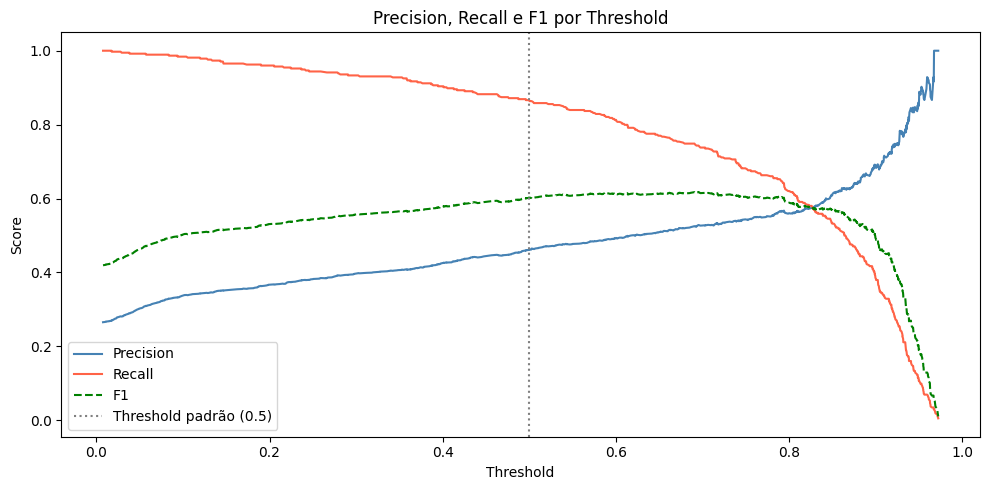

Threshold que maximiza F1: 0.70
F1 máximo: 0.618


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Obtém as probabilidades de churn para cada cliente
# predict_proba retorna [prob_não_cancela, prob_cancela]
y_proba = lgbm_tunado.predict_proba(X_test_v2)[:, 1]

# Calcula precision e recall para cada threshold possível
precisoes, recalls, thresholds = precision_recall_curve(y_test_v2, y_proba)

# Calcula F1 para cada threshold
f1_scores = 2 * (precisoes * recalls) / (precisoes + recalls + 1e-8)

# Plota as três métricas em função do threshold
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisoes[:-1], label='Precision', color='steelblue')
plt.plot(thresholds, recalls[:-1],   label='Recall',    color='tomato')
plt.plot(thresholds, f1_scores[:-1], label='F1',        color='green', linestyle='--')

plt.axvline(x=0.5, color='gray', linestyle=':', label='Threshold padrão (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall e F1 por Threshold')
plt.legend()
plt.tight_layout()
plt.show()

# Mostra o threshold que maximiza o F1
melhor_threshold = thresholds[f1_scores[:-1].argmax()]
print(f"Threshold que maximiza F1: {melhor_threshold:.2f}")
print(f"F1 máximo: {f1_scores[:-1].max():.3f}")

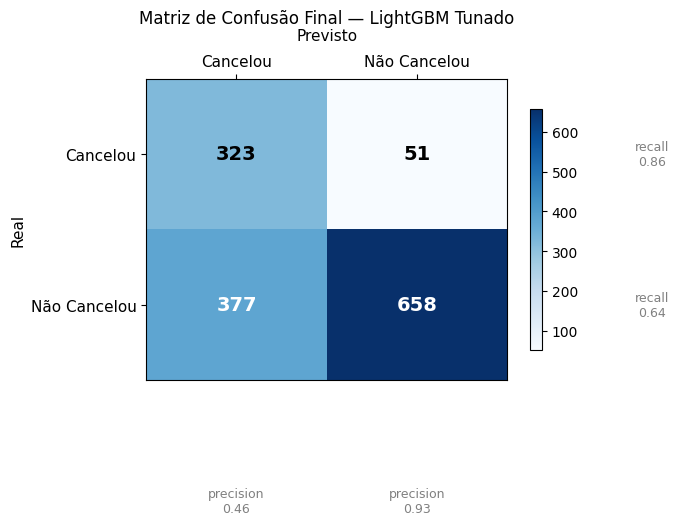

In [25]:
# Aplica o threshold 0.5 para classificação final
threshold_escolhido = 0.5
y_pred_final = (y_proba >= threshold_escolhido).astype(int)

# Matriz de confusão final
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_v2, y_pred_final)
cm_reorg = cm[::-1, ::-1]

precision_c  = cm_reorg[0,0] / (cm_reorg[0,0] + cm_reorg[1,0])
precision_nc = cm_reorg[1,1] / (cm_reorg[1,1] + cm_reorg[0,1])
recall_c     = cm_reorg[0,0] / (cm_reorg[0,0] + cm_reorg[0,1])
recall_nc    = cm_reorg[1,1] / (cm_reorg[1,1] + cm_reorg[1,0])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_reorg, cmap='Blues', aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)

classes = ['Cancelou', 'Não Cancelou']
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(classes, fontsize=11)
ax.set_yticklabels(classes, fontsize=11)
ax.set_xlabel('Previsto', fontsize=11, labelpad=10)
ax.set_ylabel('Real', fontsize=11)

thresh = cm_reorg.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_reorg[i, j]),
                ha='center', va='center', fontsize=14, fontweight='bold',
                color='white' if cm_reorg[i, j] > thresh else 'black')

for i, recall in enumerate([recall_c, recall_nc]):
    ax.text(2.3, i, f'recall\n{recall:.2f}',
            ha='center', va='center', fontsize=9, color='gray')

for j, precision in enumerate([precision_c, precision_nc]):
    ax.text(j, 2.3, f'precision\n{precision:.2f}',
            ha='center', va='center', fontsize=9, color='gray')

plt.title('Matriz de Confusão Final — LightGBM Tunado', pad=40, fontsize=12)
plt.tight_layout()
plt.show()

In [26]:
import os

# Lista os arquivos salvos na pasta models
arquivos = os.listdir('/home/jander/churn_telco/models/')
print("Arquivos em models/:")
for arquivo in arquivos:
    print(f"  {arquivo}")

Arquivos em models/:
  lgbm_churn.pkl
  scaler.pkl
